# Calling DiffABM.jl from Python

## Requirements:

- You need a working installation of Julia and you need to install this package via:

```julia
using Pkg
Pkg.add("https://github.com/arnauqb/DiffABM.jl")
```

In [1]:
from julia.api import Julia
jl = Julia(compiled_modules=False)

/Users/arnull/miniconda3/envs/torch2/lib/python3.10/site-packages/julia/juliainfo.py:93: UserWarning: julia warned:
The latest version of Julia in the `release` channel is 1.11.1+0.aarch64.apple.darwin14. You currently have `1.10.4+0.aarch64.apple.darwin14` installed. Run:

  juliaup update

in your terminal shell to install Julia 1.11.1+0.aarch64.apple.darwin14 and update the `release` channel to that version.
  warnings.warn("{} warned:\n{}".format(julia, stderr))


In [2]:
from julia import Main
Main.eval("using Pkg")
Main.eval("Pkg.activate(\"..\")") # change to environment where you installed DiffABM.jl

  Activating project at `~/code/DiffABM.jl`


In [3]:
Main.eval("using DiffABM")

┌ Warning: Package cuDNN not found in current path.
│ - Run `import Pkg; Pkg.add("cuDNN")` to install the cuDNN package, then restart julia.
│ - If cuDNN is not installed, some Flux functionalities will not be available when running on the GPU.
└ @ FluxCUDAExt ~/.julia/packages/Flux/MtsAN/ext/FluxCUDAExt/FluxCUDAExt.jl:57


In [4]:
# Axtell Firms example
julia_script = """
    using DiffABM
    using StatsBase
    using Random
    using Distributions

    function make_axtell_params(theta_bounds, initial_effort_bounds, a, b)
        n_agents = 1000
        n_timesteps = 100
        update_rate = 0.05
        delta_t = 1.0
        gradient_horizon = 200
        neighbors = [sample(1:n_agents, rand(2:6), replace = false) for _ in 1:n_agents]
        agent_initializer = RandomAxtellAgentInitializer(n_agents, theta_bounds, initial_effort_bounds, neighbors)
        return AxtellFirmsParams(agent_initializer, [a], [b], update_rate, delta_t, n_timesteps, gradient_horizon)
    end
"""
Main.eval(julia_script)

def run_axtell_model(theta_bounds, initial_effort_bounds, a, b):
    abm_params = Main.make_axtell_params(theta_bounds, initial_effort_bounds, a, b)
    return Main.abm_run(abm_params)


In [5]:
x = run_axtell_model([0.1, 0.9], [0.0, 1.0], 1.5, 2.0)

Text(0.5, 0, 'timestep')

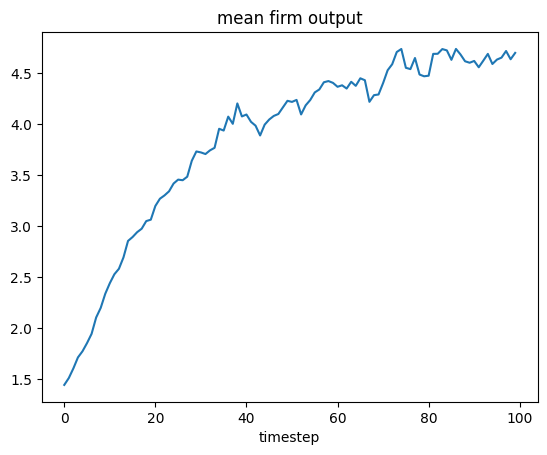

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(x[0,:])
ax.set_title("mean firm output")
ax.set_xlabel("timestep")